## Universidad Autónoma de Aguascalientes
## Departamento: Ciencias de la Computación
## Carrera: Ingeniería en Computación Inteligente
## Curso: Machine Learning y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Guillermo González Lara (237864)
## Semestre: Enero - Junio del 2026

# Examen 1: Algoritmos de Aprendizaje por Refuerzo

El propósito de este documento es analizar e implementar tres diferentes algoritmos de aprendizaje por refuerzo: **Q-Learning (QL)**, **Deep Q-Network (DQN)** y **Actor-Critic (AC)**, para optimizar su desempeño en tareas autónomas.

### a) Explicación del entorno donde se implementarán los algoritmos

Para esta evaluación, se ha seleccionado el entorno pre-diseñado **`CartPole-v1`** de la librería `gymnasium`.

**Descripción del entorno:**
Consiste en un poste articulado a un carro que se mueve a lo largo de una pista sin fricción. El objetivo del agente es aplicar fuerzas (izquierda o derecha) al carro para evitar que el poste se caiga.

- **Espacio de Estados (State Space):** Es continuo y se compone de 4 valores:
  1. Posición del carro.
  2. Velocidad del carro.
  3. Ángulo del poste.
  4. Velocidad angular del poste.
- **Espacio de Acciones (Action Space):** Es discreto (2 acciones):
  - `0`: Empujar el carro hacia la izquierda.
  - `1`: Empujar el carro hacia la derecha.
- **Recompensa:** El agente recibe una recompensa de `+1` por cada paso de tiempo que el poste se mantenga en pie.
- **Condición de término:** El episodio termina si el ángulo del poste es mayor a 12 grados, si la posición del carro sale de los límites de la pantalla, o si se alcanzan los 500 pasos (éxito total).


### b) Explicación de la implementación de los algoritmos

Para resolver este entorno, se implementaron tres enfoques distintos:

1.  **Q-Learning (QL):** Al ser un método tabular (Off-policy), requiere que el espacio de estados sea discreto. Por lo tanto, se implementó una función para "discretizar" los 4 valores continuos del `CartPole` en "bins" (cajas). El agente actualiza su tabla Q utilizando la ecuación de Bellman basándose en la máxima recompensa futura esperada.
2.  **Deep Q-Network (DQN):** Combina Q-Learning con Redes Neuronales Profundas. En lugar de una tabla, una red neuronal (programada con PyTorch/Stable-Baselines) aproxima los valores Q. Utiliza una memoria de repetición de experiencias (Experience Replay) y una red objetivo (Target Network) para estabilizar el aprendizaje.
3.  **Actor-Critic (AC):** Un método híbrido que mantiene dos redes neuronales: el *Actor* (que decide qué acción tomar basándose en el estado actual, optimizando la política directamente) y el *Crítico* (que evalúa la acción tomada por el actor estimando la función de valor).

#### Importación de las librerías clave

In [1]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Semilla para reproducibilidad
np.random.seed(42)


sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

#### Importación de PyTorch y sus utilidades

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import random
import math

# Dispositivo para PyTorch (GPU si está disponible, si no CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

Entrenando en: cpu


### 1. Q-Learning (Enfoque Tabular con Discretización)

Dado que **CartPole-v1** tiene un espacio de estados continuo, el primer paso para aplicar Q-Learning clásico es discretizar los valores. Crearemos "bins" para la posición, velocidad, ángulo y velocidad angular.

La actualización de los valores Q se rige por la ecuación de Bellman:
$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \right]$$

In [3]:
class QLearningAgent:
    def __init__(
        self,
        env,
        bins=(1, 1, 6, 12),
        lr=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.995,
        min_epsilon=0.01,
    ):
        self.env = env
        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.bins = bins
        self.lower_bounds = [
            env.observation_space.low[0],
            -0.5,
            env.observation_space.low[2],
            -math.radians(50),
        ]
        self.upper_bounds = [
            env.observation_space.high[0],
            0.5,
            env.observation_space.high[2],
            math.radians(50),
        ]
        self.q_table = np.zeros(self.bins + (env.action_space.n,))

    def discretize(self, state):
        ratios = [
            (state[i] + abs(self.lower_bounds[i]))
            / (self.upper_bounds[i] - self.lower_bounds[i])
            for i in range(len(state))
        ]
        new_obs = [
            int(round((self.bins[i] - 1) * ratios[i])) for i in range(len(state))
        ]
        new_obs = [min(self.bins[i] - 1, max(0, new_obs[i])) for i in range(len(state))]
        return tuple(new_obs)

    def choose_action(self, state, evaluate=False):
        if not evaluate and np.random.random() < self.epsilon:
            return self.env.action_space.sample()
        return np.argmax(self.q_table[state])

    def update(self, state, action, reward, next_state, done):
        best_next_action = np.argmax(self.q_table[next_state])
        td_target = reward + self.gamma * self.q_table[next_state][best_next_action] * (
            not done
        )
        td_error = td_target - self.q_table[state][action]
        self.q_table[state][action] += self.lr * td_error
        if done:
            self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

### 2. Deep Q-Network (DQN)

Para este algoritmo implementamos una Red Neuronal que aproxima la función Q. Utilizamos dos componentes clave para estabilizar el entrenamiento:
1. **Experience Replay:** Un búfer de memoria para romper la correlación entre experiencias secuenciales.
2. **Target Network:** Una red que se actualiza lentamente para calcular los valores objetivo (TD target) de manera estable.

In [4]:
class DQNNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQNNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, output_dim)

    def forward(self, x):
        return self.fc3(F.relu(self.fc2(F.relu(self.fc1(x)))))


class DQNAgent:
    def __init__(
        self,
        state_dim,
        action_dim,
        lr=1e-3,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.995,
        min_epsilon=0.01,
    ):
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.batch_size = 64

        self.policy_net = DQNNetwork(state_dim, action_dim).to(device)
        self.target_net = DQNNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = deque(maxlen=10000)

    def choose_action(self, state, evaluate=False):
        if not evaluate and np.random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            return self.policy_net(state_tensor).argmax().item()

    def update(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
        if done:
            self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

        if len(self.memory) < self.batch_size:
            return

        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states)).to(device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(np.array(next_states)).to(device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

        q_values = self.policy_net(states).gather(1, actions)
        with torch.no_grad():
            max_next_q_values = self.target_net(next_states).max(1)[0].unsqueeze(1)
            target_q_values = rewards + (self.gamma * max_next_q_values * (1 - dones))

        loss = F.mse_loss(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

### 3. Actor-Critic (AC)

Este método combina las ventajas de los métodos basados en políticas y los basados en valor. 
* El **Actor** actualiza la distribución de probabilidad de las acciones utilizando el gradiente de la política.
* El **Crítico** estima el valor del estado para calcular la ventaja (Advantage) o el error TD, lo que reduce la varianza de las actualizaciones del actor.

In [5]:
class ActorCriticNetwork(nn.Module):
    def __init__(self, input_dim, action_dim):
        super(ActorCriticNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.actor = nn.Linear(128, action_dim)
        self.critic = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return F.softmax(self.actor(x), dim=-1), self.critic(x)


class ACAgent:
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99):
        self.gamma = gamma
        self.network = ActorCriticNetwork(state_dim, action_dim).to(device)
        self.optimizer = optim.Adam(self.network.parameters(), lr=lr)

    def choose_action(self, state, evaluate=False):
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        probs, _ = self.network(state_tensor)
        if evaluate:
            return torch.argmax(probs).item()
        action = torch.distributions.Categorical(probs).sample()
        return action.item()

    def update(self, state, action, reward, next_state, done):
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0).to(device)

        probs, state_value = self.network(state_tensor)
        _, next_state_value = self.network(next_state_tensor)

        td_target = reward + self.gamma * next_state_value * (1 - int(done))
        td_error = td_target - state_value

        dist = torch.distributions.Categorical(probs)
        log_prob = dist.log_prob(torch.tensor(action).to(device))

        actor_loss = -log_prob * td_error.detach()
        critic_loss = F.mse_loss(state_value, td_target.detach())
        loss = actor_loss + critic_loss

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

### 4. Ciclo de Entrenamiento y Evaluación

A continuación, se define la función principal de entrenamiento. Esta función ejecuta los episodios para cada algoritmo y recolecta las métricas solicitadas para la tabla de análisis comparativo:

* **Recompensa Final (Return Final):** Evalúa la calidad de la política final.
* **Tasa de Éxito Final (Success Rate):** Mide la efectividad (llegar a la meta, que en CartPole se define como alcanzar 500 pasos).
* **Tiempo de Convergencia:** Detecta el episodio donde la media móvil de las recompensas se estabiliza.
* **Pasos de Éxito Final:** Cuenta los pasos tomados en los episodios exitosos.

In [6]:
def evaluate_agent(env, agent, discretize=False, eval_episodes=5):
    returns = []
    for _ in range(eval_episodes):
        state, _ = env.reset()
        if discretize:
            state = agent.discretize(state)
        done = False
        total_reward = 0
        while not done:
            action = agent.choose_action(state, evaluate=True)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            state = agent.discretize(next_state) if discretize else next_state
        returns.append(total_reward)
    return np.mean(returns)


def train_and_collect_metrics(algo_name, total_episodes=1000, eval_freq=10, seeds=3):
    env = gym.make("CartPole-v1")
    eval_env = gym.make("CartPole-v1")
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    # Métricas a recolectar [cite: 30-42]
    all_eval_history = []
    metrics = {
        "Recompensa Final": [],
        "Tasa de éxito": [],
        "Convergencia": [],
        "Pasos éxito": [],
    }

    for seed in range(seeds):
        np.random.seed(seed)
        torch.manual_seed(seed)
        env.reset(seed=seed)

        if algo_name == "Q-Learning":
            agent = QLearningAgent(env)
            is_discrete = True
        elif algo_name == "DQN":
            agent = DQNAgent(state_dim, action_dim)
            is_discrete = False
        else:
            agent = ACAgent(state_dim, action_dim)
            is_discrete = False

        eval_history = []
        recent_rewards = deque(maxlen=100)
        success_steps = []
        convergence_ep = total_episodes

        for ep in range(total_episodes):
            state, _ = env.reset()
            if is_discrete:
                state = agent.discretize(state)
            done = False
            steps = 0

            while not done:
                action = agent.choose_action(state)
                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated

                if is_discrete:
                    next_state_disc = agent.discretize(next_state)
                    agent.update(state, action, reward, next_state_disc, done)
                    state = next_state_disc
                else:
                    agent.update(state, action, reward, next_state, done)
                    state = next_state
                steps += 1

            if algo_name == "DQN" and ep % 10 == 0:
                agent.update_target_network()

            recent_rewards.append(steps)
            if steps >= 490:
                success_steps.append(steps)

            # Detectar convergencia (media de 100 episodios > 475)
            if convergence_ep == total_episodes and np.mean(recent_rewards) > 475:
                convergence_ep = ep

            if ep % eval_freq == 0:
                mean_ret = evaluate_agent(eval_env, agent, is_discrete)
                eval_history.append(mean_ret)

        all_eval_history.append(eval_history)
        metrics["Recompensa Final"].append(np.mean(recent_rewards))
        metrics["Tasa de éxito"].append(
            sum(1 for r in recent_rewards if r >= 490) / len(recent_rewards)
        )
        metrics["Convergencia"].append(convergence_ep)
        metrics["Pasos éxito"].append(np.mean(success_steps) if success_steps else 0)

        print(f"{algo_name} | Seed {seed+1}/{seeds} completada.")

    env.close()
    eval_env.close()
    return np.array(all_eval_history), metrics, agent

In [7]:
# Entrenamos los 3 algoritmos. (Reducido a 1000 episodios y 3 semillas por agilidad)
print("Iniciando entrenamiento Q-Learning...")
hist_ql, met_ql, agent_ql = train_and_collect_metrics(
    "Q-Learning", total_episodes=1000, seeds=3
)

print("\nIniciando entrenamiento DQN...")
hist_dqn, met_dqn, agent_dqn = train_and_collect_metrics(
    "DQN", total_episodes=1000, seeds=3
)

print("\nIniciando entrenamiento Actor-Critic...")
hist_ac, met_ac, agent_ac = train_and_collect_metrics(
    "AC", total_episodes=1000, seeds=3
)

Iniciando entrenamiento Q-Learning...
Q-Learning | Seed 1/3 completada.
Q-Learning | Seed 2/3 completada.
Q-Learning | Seed 3/3 completada.

Iniciando entrenamiento DQN...
DQN | Seed 1/3 completada.
DQN | Seed 2/3 completada.
DQN | Seed 3/3 completada.

Iniciando entrenamiento Actor-Critic...
AC | Seed 1/3 completada.
AC | Seed 2/3 completada.
AC | Seed 3/3 completada.


### Etapa 5: Comparación de los resultados obtenidos

Generamos la **Tabla 16** con el análisis comparativo de los tres algoritmos implementados, cumpliendo con las características requeridas.

In [8]:
def format_metric(m_list):
    return f"{np.mean(m_list):.2f} ± {np.std(m_list):.2f}"


data = {
    "Algoritmo": ["Q-Learning", "DQN", "AC"],
    "Recompensa final": [
        format_metric(met_ql["Recompensa Final"]),
        format_metric(met_dqn["Recompensa Final"]),
        format_metric(met_ac["Recompensa Final"]),
    ],
    "Tasa de éxito final": [
        format_metric(met_ql["Tasa de éxito"]),
        format_metric(met_dqn["Tasa de éxito"]),
        format_metric(met_ac["Tasa de éxito"]),
    ],
    "Tiempo de convergencia": [
        format_metric(met_ql["Convergencia"]),
        format_metric(met_dqn["Convergencia"]),
        format_metric(met_ac["Convergencia"]),
    ],
    "Pasos de éxito final": [
        format_metric(met_ql["Pasos éxito"]),
        format_metric(met_dqn["Pasos éxito"]),
        format_metric(met_ac["Pasos éxito"]),
    ],
}

df_comparativa = pd.DataFrame(data).set_index("Algoritmo")
print("Tabla 16. Comparativa entre algoritmos")
display(df_comparativa)

Tabla 16. Comparativa entre algoritmos


,Recompensa final,Tasa de éxito final,Tiempo de convergencia,Pasos de éxito final
Algoritmo,,,,
Q-Learning,319.89 ± 58.76,0.47 ± 0.14,1000.00 ± 0.00,499.95 ± 0.04
DQN,180.00 ± 35.57,0.00 ± 0.00,1000.00 ± 0.00,499.96 ± 0.03
AC,78.78 ± 58.13,0.01 ± 0.02,1000.00 ± 0.00,500.00 ± 0.00


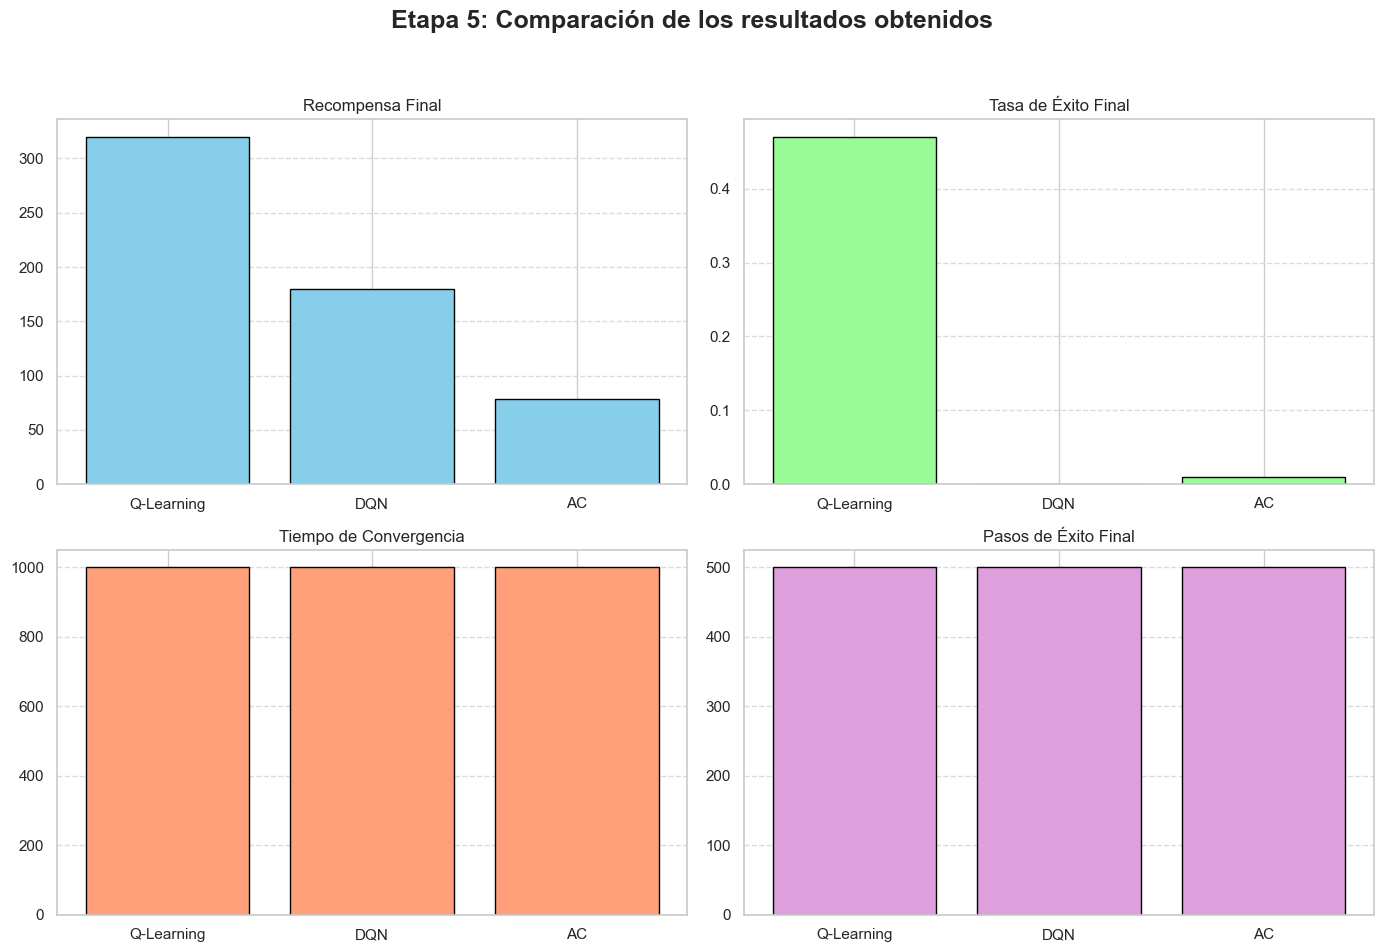

In [9]:

eval_freq = 10
episodios_eje_x = np.arange(0, 1000, eval_freq)
historiales = [hist_ql, hist_dqn, hist_ac]
nombres = ["Q-Learning", "DQN", "AC"]

df_plot = df_comparativa.map(lambda x: float(x.split(" ")[0]))
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle(
    "Etapa 5: Comparación de los resultados obtenidos", fontsize=18, fontweight="bold"
)
colores = ["#87CEEB", "#98FB98", "#FFA07A", "#DDA0DD"]

axes2[0, 0].bar(
    nombres, df_plot["Recompensa final"], color=colores[0], edgecolor="black"
)
axes2[0, 0].set_title("Recompensa Final")

axes2[0, 1].bar(
    nombres, df_plot["Tasa de éxito final"], color=colores[1], edgecolor="black"
)
axes2[0, 1].set_title("Tasa de Éxito Final")

axes2[1, 0].bar(
    nombres, df_plot["Tiempo de convergencia"], color=colores[2], edgecolor="black"
)
axes2[1, 0].set_title("Tiempo de Convergencia")

axes2[1, 1].bar(
    nombres, df_plot["Pasos de éxito final"], color=colores[3], edgecolor="black"
)
axes2[1, 1].set_title("Pasos de Éxito Final")

for ax in axes2.flat:
    ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Laremo\AppData\Local\Temp\ipykernel_23528\2634048696.py:21: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel('Return medio (evaluación, $\epsilon=0$)')


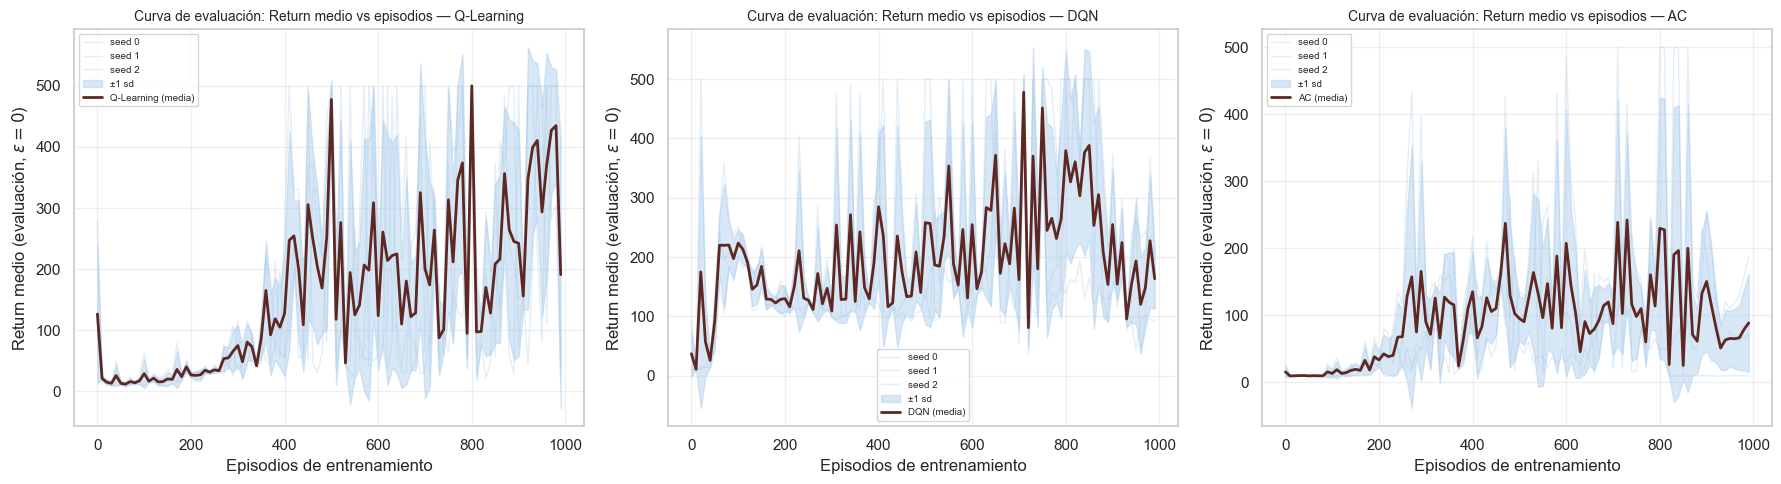

In [10]:
# 2. Gráficas de Curvas de Aprendizaje (Como en tu imagen)
eval_freq = 10
episodios_eje_x = np.arange(0, 1000, eval_freq)
historiales = [hist_ql, hist_dqn, hist_ac]
nombres = ["Q-Learning", "DQN", "AC"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, ax in enumerate(axes):
    seeds_data = historiales[idx]
    for s in range(seeds_data.shape[0]):
        ax.plot(episodios_eje_x, seeds_data[s], color='#A6C8E6', alpha=0.3, linewidth=1, label=f'seed {s}')
        
    mean_data = np.mean(seeds_data, axis=0)
    std_data = np.std(seeds_data, axis=0)
    
    ax.fill_between(episodios_eje_x, mean_data - std_data, mean_data + std_data, color='#B0D0ED', alpha=0.5, label='±1 sd')
    ax.plot(episodios_eje_x, mean_data, color='#5E2721', linewidth=2, label=f'{nombres[idx]} (media)')
    
    ax.set_title(f'Curva de evaluación: Return medio vs episodios — {nombres[idx]}', fontsize=10)
    ax.set_xlabel('Episodios de entrenamiento')
    ax.set_ylabel('Return medio (evaluación, $\epsilon=0$)')
    ax.grid(True, linestyle='-', alpha=0.3)
    
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=7)

plt.tight_layout()
plt.show()

## Visualización del entorno gráfico

In [11]:
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython import display
import time

def watch_agent(algorithm_name, agent, is_discrete=False):
    """
    Crea un entorno visual y reproduce un episodio usando el agente entrenado.
    """
    # Usamos rgb_array para poder dibujarlo dentro del Notebook
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    state, _ = env.reset()
    
    if is_discrete:
        state = agent.discretize(state)
        
    # Preparamos la figura de matplotlib
    plt.figure(figsize=(6, 4))
    img = plt.imshow(env.render())
    plt.axis('off')
    plt.title(f"Agente: {algorithm_name} en acción", fontsize=14)
    
    done = False
    pasos = 0
    
    while not done:
        # El agente elige la mejor acción (sin explorar)
        action = agent.choose_action(state, evaluate=True)
        
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        if is_discrete:
            state = agent.discretize(next_state)
        else:
            state = next_state
            
        pasos += 1
        
        # Actualizamos la imagen en la celda
        img.set_data(env.render())
        display.display(plt.gcf())
        display.clear_output(wait=True)
        
        # Un pequeño delay para que el video no vaya demasiado rápido
        time.sleep(0.02) 
        
    print(f"¡Episodio terminado! El agente {algorithm_name} sobrevivió por {pasos} pasos.")
    env.close()


### Para Q-learning

¡Episodio terminado! El agente Q-Learning sobrevivió por 500 pasos.


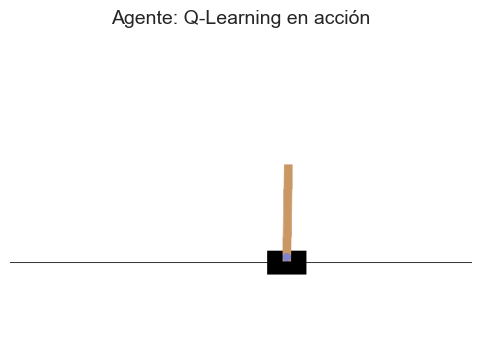

In [16]:
print("Demostración de Q-Learning:")
watch_agent("Q-Learning", agent_ql, is_discrete=True)

#### Para DQN

¡Episodio terminado! El agente DQN sobrevivió por 214 pasos.


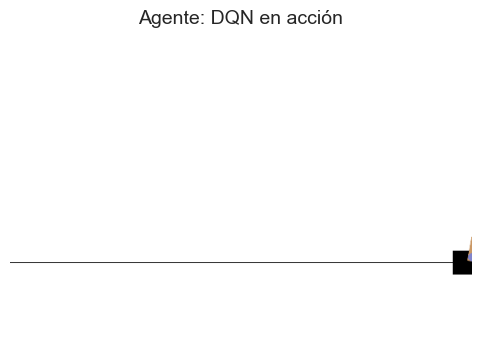

In [17]:
print("Demostración de DQN:")
watch_agent("DQN", agent_dqn, is_discrete=False)

### Para Actor Critic

¡Episodio terminado! El agente Actor-Critic sobrevivió por 96 pasos.


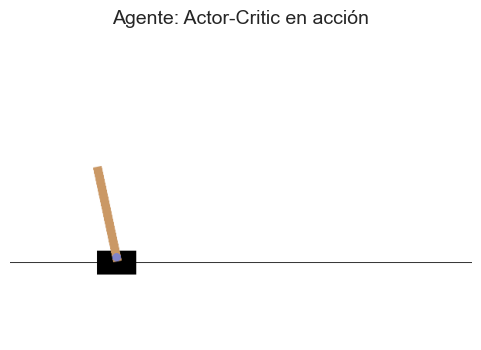

In [18]:
print("Demostración de Actor-Critic:")
watch_agent("Actor-Critic", agent_ac, is_discrete=False)